In [25]:
import matplotlib.pyplot as plt
import numpy as np

In [26]:
import torch
import torch.nn as nn

import torchvision
from torchvision import transforms

In [27]:
image_path = "./datasets/"
celeba_train_dataset = torchvision.datasets.CelebA(
    image_path, split="train", target_type="attr", download=False
)

celeba_valid_dataset = torchvision.datasets.CelebA(
    image_path, split="valid", target_type="attr", download=False
)
celeba_test_dataset = torchvision.datasets.CelebA(
    image_path, split="test", target_type="attr", download=False
)

In [28]:
len(celeba_test_dataset)

19962

#### Data Augmentation

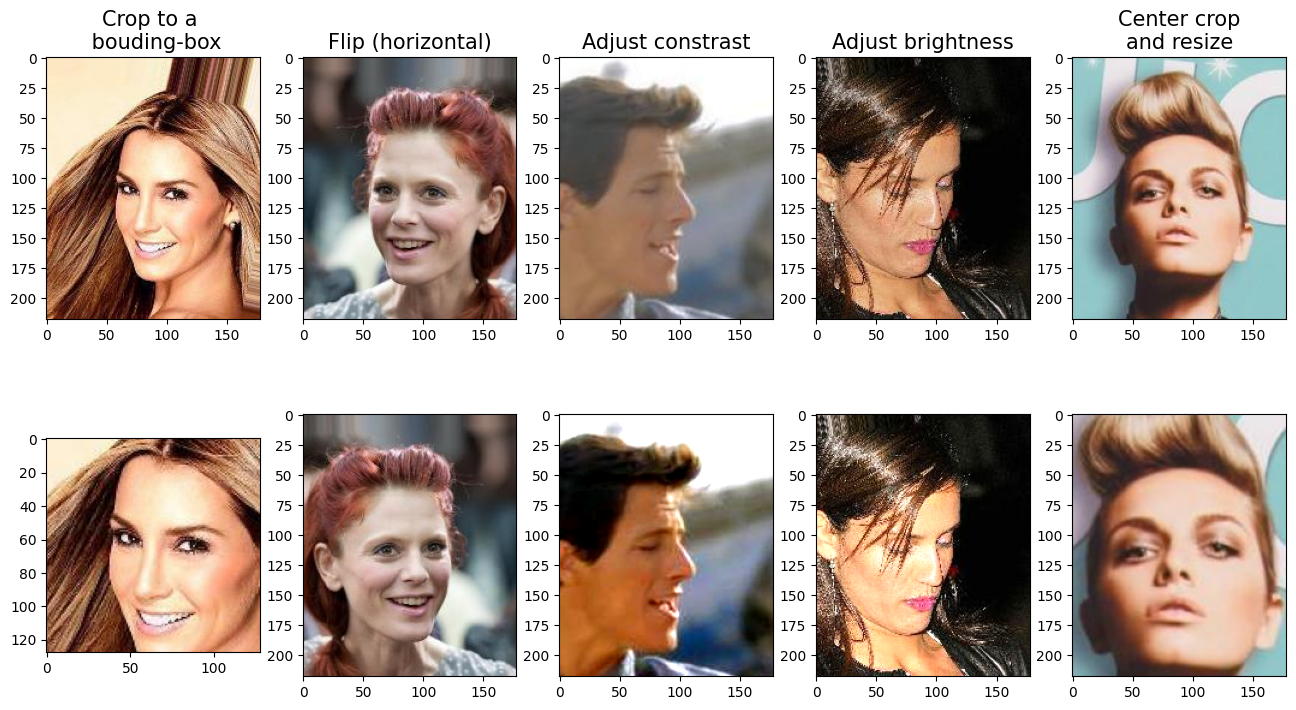

In [11]:
fig = plt.figure(figsize=(16, 8.5))

# Col1: Cropping to a bouding box
ax = fig.add_subplot(2, 5, 1)
img, attr = celeba_train_dataset[0]
ax.set_title("Crop to a \n bouding-box", size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 6)
img_cropped = transforms.functional.crop(img, 50, 20, 128, 128)
ax.imshow(img_cropped)

# Col2: Flipping horizontally
ax = fig.add_subplot(2, 5, 2)
img, attr = celeba_train_dataset[1]
ax.set_title("Flip (horizontal)", size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 7)
img_cropped = transforms.functional.hflip(img)
ax.imshow(img_cropped)

## Column 3: adjust contrast
ax = fig.add_subplot(2, 5, 3)
img, attr = celeba_train_dataset[2]
ax.set_title("Adjust constrast", size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 8)
img_adj_contrast = transforms.functional.adjust_contrast(img, contrast_factor=2)
ax.imshow(img_adj_contrast)

## Column 4: adjust brightness
ax = fig.add_subplot(2, 5, 4)
img, attr = celeba_train_dataset[3]
ax.set_title("Adjust brightness", size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 9)
img_adj_brightness = transforms.functional.adjust_brightness(img, brightness_factor=1.3)
ax.imshow(img_adj_brightness)

## Column 5: cropping from image center
ax = fig.add_subplot(2, 5, 5)
img, attr = celeba_train_dataset[4]
ax.set_title("Center crop\nand resize", size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 10)
img_center_crop = transforms.functional.center_crop(img, [0.7 * 218, 0.7 * 178])
img_resized = transforms.functional.resize(img_center_crop, size=(218, 178))
ax.imshow(img_resized)

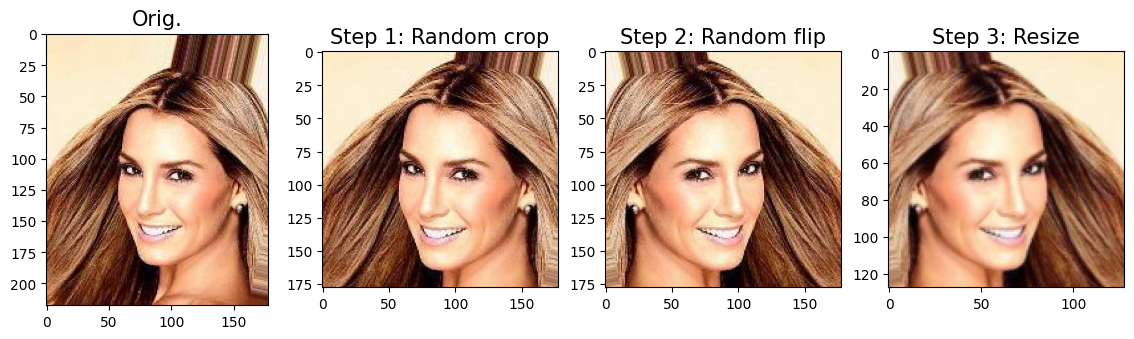

In [ ]:
torch.manual_seed(1)

fig = plt.figure(figsize=(14, 12))

for i, (img, attr) in enumerate(celeba_train_dataset):
    ax = fig.add_subplot(3, 4, i * 4 + 1)
    ax.imshow(img)
    if i == 0:
        ax.set_title("Orig.", size=15)

    ax = fig.add_subplot(3, 4, i * 4 + 2)
    img_transform = transforms.Compose([transforms.RandomCrop([178, 178])])
    img_cropped = img_transform(img)
    ax.imshow(img_cropped)
    if i == 0:
        ax.set_title("Step 1: Random crop", size=15)

    ax = fig.add_subplot(3, 4, i * 4 + 3)
    img_transform = transforms.Compose([transforms.RandomHorizontalFlip()])
    img_flip = img_transform(img_cropped)
    ax.imshow(img_flip)
    if i == 0:
        ax.set_title("Step 2: Random flip", size=15)

    ax = fig.add_subplot(3, 4, i * 4 + 4)
    img_resized = transforms.functional.resize(img_flip, size=(128, 128))
    ax.imshow(img_resized)
    if i == 0:
        ax.set_title("Step 3: Resize", size=15)
        break

    # if i == 2:
    #     break
plt.show()

In [29]:
get_smile = lambda attr: attr[18]

In [30]:
#  apply data augmentation to the training examples only
transform_train = transforms.Compose(
    [
        transforms.RandomCrop([178, 178]),
        transforms.RandomHorizontalFlip(),
        transforms.Resize([64, 64]),
        transforms.ToTensor(),
    ]
)

transform = transforms.Compose(
    [
        transforms.CenterCrop([178, 178]),
        transforms.Resize([64, 64]),
        transforms.ToTensor(),
    ]
)

In [45]:
from torch.utils.data import DataLoader, Subset

celeba_train_dataset = torchvision.datasets.CelebA(
    image_path,
    split="train",
    target_type="attr",
    download=False,
    transform=transform_train,
    target_transform=get_smile,
)


celeba_valid_dataset = torchvision.datasets.CelebA(
    image_path,
    split="valid",
    target_type="attr",
    download=False,
    transform=transform,
    target_transform=get_smile,
)

celeba_test_dataset = torchvision.datasets.CelebA(
    image_path,
    split="test",
    target_type="attr",
    download=False,
    transform=transform,
    target_transform=get_smile,
)


celeba_train_dataset = Subset(celeba_train_dataset, torch.arange(16000))
celeba_valid_dataset = Subset(celeba_valid_dataset, torch.arange(1000))

print("Train set:", len(celeba_train_dataset))
print("Validation set:", len(celeba_valid_dataset))

Train set: 16000
Validation set: 1000


In [47]:
def check_output(model: nn.Module):
    x = torch.ones((4, 3, 64, 64))
    return model(x).shape

In [48]:
batch_size = 32

torch.manual_seed(1)
train_dl = DataLoader(celeba_train_dataset, batch_size, shuffle=True)
valid_dl = DataLoader(celeba_valid_dataset, batch_size, shuffle=False)
test_dl = DataLoader(celeba_test_dataset, batch_size, shuffle=False)

### Training a CNN Smile Classifier

In [49]:
model = nn.Sequential()

model.add_module("conv1", nn.Conv2d(3, 32, kernel_size=3, padding=1))
model.add_module("relu1", nn.ReLU())
model.add_module("pool1", nn.MaxPool2d(kernel_size=2))
model.add_module("dropout1", nn.Dropout(p=0.5))

model.add_module("conv2", nn.Conv2d(32, 64, kernel_size=3, padding=1))
model.add_module("relu2", nn.ReLU())
model.add_module("pool2", nn.MaxPool2d(kernel_size=2))
model.add_module("dropout2", nn.Dropout(p=0.5))

model.add_module("conv3", nn.Conv2d(64, 128, kernel_size=3, padding=1))
model.add_module("relu3", nn.ReLU())
model.add_module("pool3", nn.MaxPool2d(kernel_size=2))

model.add_module("conv4", nn.Conv2d(128, 256, kernel_size=3, padding=1))
model.add_module("relu4", nn.ReLU())

In [50]:
check_output(model)

torch.Size([4, 256, 8, 8])

In [51]:
model.add_module("pool4", nn.AvgPool2d(kernel_size=8))
model.add_module("flatten", nn.Flatten())

In [52]:
check_output(model)

torch.Size([4, 256])

In [53]:
model.add_module("fc", nn.Linear(256, 1))
model.add_module("sigmoid", nn.Sigmoid())

In [54]:
check_output(model)

torch.Size([4, 1])

In [55]:
model

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.5, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (pool4): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [56]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [57]:
device = torch.device("cuda:0")
# device = torch.device("cpu")
model = model.to(device)

In [58]:
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch.float())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = ((pred >= 0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum().cpu()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                pred = model(x_batch)[:, 0]
                loss = loss_fn(pred, y_batch.float())
                loss_hist_valid[epoch] += loss.item() * y_batch.size(0)
                is_correct = ((pred >= 0.5).float() == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum().cpu()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)

        print(
            f"Epoch {epoch + 1} accuracy: {accuracy_hist_train[epoch]:.4f} val_accuracy: {accuracy_hist_valid[epoch]:.4f}"
        )
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

In [59]:
torch.manual_seed(1)
num_epochs = 30
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.6215 val_accuracy: 0.7170
Epoch 2 accuracy: 0.7040 val_accuracy: 0.7160
Epoch 3 accuracy: 0.7265 val_accuracy: 0.7770
Epoch 4 accuracy: 0.7445 val_accuracy: 0.7870
Epoch 5 accuracy: 0.7541 val_accuracy: 0.7690
Epoch 6 accuracy: 0.7678 val_accuracy: 0.7730
Epoch 7 accuracy: 0.7706 val_accuracy: 0.7910
Epoch 8 accuracy: 0.7818 val_accuracy: 0.8130
Epoch 9 accuracy: 0.7976 val_accuracy: 0.8040
Epoch 10 accuracy: 0.8123 val_accuracy: 0.8250
Epoch 11 accuracy: 0.8249 val_accuracy: 0.8460
Epoch 12 accuracy: 0.8324 val_accuracy: 0.8530
Epoch 13 accuracy: 0.8408 val_accuracy: 0.8550
Epoch 14 accuracy: 0.8454 val_accuracy: 0.8460
Epoch 15 accuracy: 0.8526 val_accuracy: 0.8710
Epoch 16 accuracy: 0.8498 val_accuracy: 0.8630
Epoch 17 accuracy: 0.8575 val_accuracy: 0.8750
Epoch 18 accuracy: 0.8593 val_accuracy: 0.8750
Epoch 19 accuracy: 0.8637 val_accuracy: 0.8670
Epoch 20 accuracy: 0.8612 val_accuracy: 0.8820
Epoch 21 accuracy: 0.8602 val_accuracy: 0.8670
Epoch 22 accuracy: 0.8

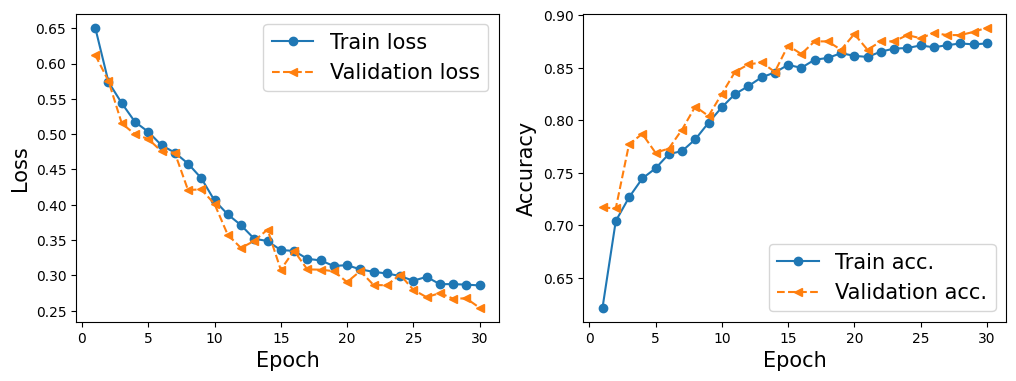

In [60]:
x_arr = np.arange(len(hist[0])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], "-o", label="Train loss")
ax.plot(x_arr, hist[1], "--<", label="Validation loss")
ax.legend(fontsize=15)
ax.set_xlabel("Epoch", size=15)
ax.set_ylabel("Loss", size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], "-o", label="Train acc.")
ax.plot(x_arr, hist[3], "--<", label="Validation acc.")
ax.legend(fontsize=15)
ax.set_xlabel("Epoch", size=15)
ax.set_ylabel("Accuracy", size=15)
plt.show()

In [ ]:
accuracy_test = 0

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_dl:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        pred = model(x_batch)[:, 0]
        is_correct = ((pred >= 0.5).float() == y_batch).float()
        accuracy_test += is_correct.sum().cpu()

accuracy_test /= len(test_dl.dataset)

print(f"Test accuracy: {accuracy_test:.4f}")

Test accuracy: 0.8733


---